In [161]:
import yfinance as yf

In [163]:
from sklearn.model_selection import train_test_split

In [165]:
import tensorflow as tf

In [167]:
from tensorflow.keras.layers import Dense, Dropout

In [169]:
data = yf.Ticker("SPY")

In [171]:
spy  = data.history(period = '15y', auto_adjust= False)

In [172]:
spy

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,,
2010-12-27 00:00:00-05:00,125.129997,125.769997,125.040001,125.650002,96.121887,58126000,0.000,0.0,0.0
2010-12-28 00:00:00-05:00,125.900002,125.949997,125.500000,125.830002,96.259598,55309100,0.000,0.0,0.0
2010-12-29 00:00:00-05:00,125.980003,126.199997,125.900002,125.919998,96.328438,58033100,0.000,0.0,0.0
2010-12-30 00:00:00-05:00,125.800003,126.129997,125.529999,125.720001,96.175438,76616900,0.000,0.0,0.0
2010-12-31 00:00:00-05:00,125.529999,125.870003,125.330002,125.750000,96.198402,91218900,0.000,0.0,0.0
...,...,...,...,...,...,...,...,...,...
2025-12-17 00:00:00-05:00,679.890015,680.440002,671.200012,671.400024,669.421936,110625200,0.000,0.0,0.0
2025-12-18 00:00:00-05:00,677.599976,680.739990,674.900024,676.469971,674.476929,108650100,0.000,0.0,0.0
2025-12-19 00:00:00-05:00,676.590027,681.090027,676.469971,680.590027,680.590027,103599500,1.993,0.0,0.0


In [175]:
spy["mm21"] = spy["Adj Close"].rolling(21).mean()
spy["mm50"] = spy["Adj Close"].rolling(50).mean()

In [177]:
spy["target"] = spy["Adj Close"].pct_change().shift(-1)

In [179]:
spy['distancia mm21'] = (spy["Adj Close"] - spy["mm21"]) / spy["mm21"]
spy['distancia mm50'] = (spy["Adj Close"] - spy["mm50"]) / spy["mm50"]

In [181]:
spy = spy.drop(["Open", "High", "Low", "Close","Stock Splits", "Capital Gains","mm21","mm50"], axis = 1)

In [183]:
spy

,Adj Close,Volume,Dividends,target,distancia mm21,distancia mm50
Date,,,,,,
2010-12-27 00:00:00-05:00,96.121887,58126000,0.000,0.001433,NaN,NaN
2010-12-28 00:00:00-05:00,96.259598,55309100,0.000,0.000715,NaN,NaN
2010-12-29 00:00:00-05:00,96.328438,58033100,0.000,-0.001588,NaN,NaN
2010-12-30 00:00:00-05:00,96.175438,76616900,0.000,0.000239,NaN,NaN
2010-12-31 00:00:00-05:00,96.198402,91218900,0.000,0.010338,NaN,NaN
...,...,...,...,...,...,...
2025-12-17 00:00:00-05:00,669.421936,110625200,0.000,0.007551,-0.007995,-0.005088
2025-12-18 00:00:00-05:00,674.476929,108650100,0.000,0.009063,-0.001655,0.002325
2025-12-19 00:00:00-05:00,680.590027,103599500,1.993,0.006230,0.005981,0.011067


In [185]:
spy = spy.dropna()

In [187]:
spy

,Adj Close,Volume,Dividends,target,distancia mm21,distancia mm50
Date,,,,,,
2011-03-08 00:00:00-05:00,101.423309,174615000,0.000,-0.001433,0.000546,0.019830
2011-03-09 00:00:00-05:00,101.277985,153806000,0.000,-0.018506,-0.001038,0.017314
2011-03-10 00:00:00-05:00,99.403709,301291800,0.000,0.006926,-0.018598,-0.002143
2011-03-11 00:00:00-05:00,100.092224,225621800,0.000,-0.006038,-0.011292,0.004010
2011-03-14 00:00:00-04:00,99.487892,234974100,0.000,-0.011457,-0.016458,-0.002714
...,...,...,...,...,...,...
2025-12-16 00:00:00-05:00,676.869934,122030600,0.000,-0.011004,0.003447,0.006050
2025-12-17 00:00:00-05:00,669.421936,110625200,0.000,0.007551,-0.007995,-0.005088
2025-12-18 00:00:00-05:00,674.476929,108650100,0.000,0.009063,-0.001655,0.002325


In [189]:
prueba = spy.copy()

In [191]:
x = prueba.drop(["Adj Close", "target"], axis=1)
y = prueba["target"]

In [193]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42, shuffle = False)

In [195]:
from sklearn.preprocessing import StandardScaler

In [197]:
estandar = StandardScaler()

In [199]:
x_train_scaled = estandar.fit_transform(x_train)

In [201]:
x_test_scaled = estandar.transform(x_test)

In [203]:
tf.random.set_seed(42)

In [205]:
prueba.shape

(3722, 6)

In [207]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.InputLayer(shape=(x_train_scaled.shape[1],)))
model.add(tf.keras.layers.Dense(80, activation="relu",kernel_regularizer= tf.keras.regularizers.l2(0.01)))
model.add(tf.keras.layers.Dense(80, activation="relu",kernel_regularizer= tf.keras.regularizers.l2(0.01)))
model.add(Dropout(0.2))
model.add(tf.keras.layers.Dense(1,activation = 'linear'))

In [209]:
model.compile(
    loss="mae",
    optimizer="adam" 
)

In [211]:
history = model.fit(
    x_train_scaled, y_train, 
    epochs=50, 
    batch_size=32,
    validation_split=0.2, 
    verbose=1
)

Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7040 - val_loss: 0.4533
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3354 - val_loss: 0.2274
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1683 - val_loss: 0.1230
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0929 - val_loss: 0.0727
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0555 - val_loss: 0.0459
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0354 - val_loss: 0.0310
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0237 - val_loss: 0.0219
Epoch 8/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0170 - val_loss: 0.0168
Epoch 9/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0129 - val_loss: 0.0137
Epoch 10/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0105 - val_loss: 0.0119
Epoch 11/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0091 - val_loss: 0.0108
Epoch 12/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0082 - val_lo

In [213]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 80)                  │             400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 80)                  │           6,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 80)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              81 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,885 (81.59 KB)

 Trainable params: 6,961 (27.19 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,924 (54.39 KB)

In [215]:
import matplotlib.pyplot as plt 

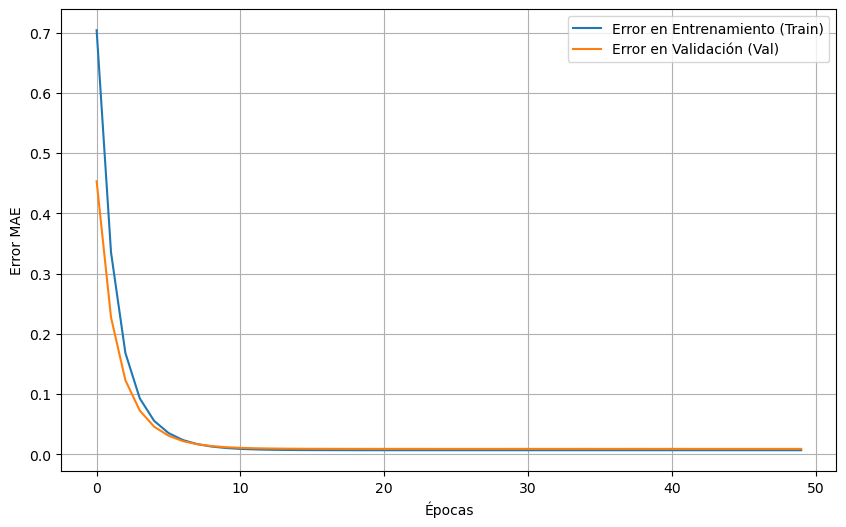

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='error en Entrenamiento (Train)')
plt.plot(history.history['val_loss'], label='error en Validacion (Val)')
plt.xlabel('epocas')
plt.ylabel('error MAE')
plt.legend()
plt.grid()
plt.show()

In [219]:
mae_test = model.evaluate(x_test_scaled, y_test, verbose=2)


24/24 - 0s - 2ms/step - loss: 0.0066


In [227]:
print(f"Baseline (LinearReg): 0.006602686795235239")
print("Test loss red neuronal:", mae_test)

Baseline (LinearReg): 0.006602686795235239
Test loss red neuronal: 0.006554761901497841


In [229]:
mae_test

0.006554761901497841

In [139]:
#pprobar keras turner

In [383]:
pip install -q -U keras-tuner

Note: you may need to restart the kernel to use updated packages.


In [231]:
from tensorflow import keras
import keras_tuner as kt

In [245]:
def build_model(hp):
    n_hidden = hp.Int("n_hidden", min_value=0,max_value=3)#nro de capas ocultas
    n_neurons = hp.Int("n_neurons", min_value= 50, max_value= 100) #nro de neuronas por capa
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")
    l2_prueba = hp.Float("l2_strength", min_value=1e-5, max_value=1e-2, sampling="log")
    dropout_rate = hp.Float("dropout_rate", min_value=0.0, max_value=0.5, step=0.1)
    optimizer = hp.Choice("optimizers", values=["sgd","adam"])
    if optimizer == "sgd":
        optimizer = tf.keras.optimizers.SGD(learning_rate = learning_rate)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate = learning_rate)
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(shape=(x_train_scaled.shape[1],)))
    for _ in range(n_hidden):
        model.add(tf.keras.layers.Dense(n_neurons, activation='relu',kernel_regularizer= tf.keras.regularizers.l2(l2_prueba)))
        model.add(tf.keras.layers.Dense(n_neurons, activation='relu',kernel_regularizer= tf.keras.regularizers.l2(l2_prueba)))
        if dropout_rate > 0:
            model.add(tf.keras.layers.Dropout(dropout_rate))
    model.add(tf.keras.layers.Dense(1, activation= 'linear'))
    model.compile(loss="mae",optimizer=optimizer, metrics = ["mse"])
    return model

In [ ]:
random_search = kt.RandomSearch(
    hypermodel=build_model,
    objective="val_loss",  
    max_trials=15,      
    executions_per_trial=1,
    overwrite=True,      
    directory="my_tuning_dir",    
    project_name="proyecto_finanzas",    
    seed=42       
)

In [254]:
random_search.search(x_train_scaled,
            y_train,
            epochs=100,
            validation_split= 0.2,
            callbacks=[tf.keras.callbacks.EarlyStopping(patience=5,monitor='val_loss')])

Trial 30 Complete [00h 00m 10s]
val_loss: 0.009094503708183765

Best val_loss So Far: 0.0090672941878438
Total elapsed time: 00h 05m 31s


In [250]:
tuner = kt.BayesianOptimization(
    hypermodel=build_model,
    objective="val_loss",
    max_trials=30,  
    directory="my_tuning_dir",
    project_name="finanzas_bayesian_v2",
    overwrite=True
)